# Notebook de prueba del modelo de plagio

Este notebook compara dos snippets de código usando el pipeline ya entrenado:
`tokenize_source` + `winnow` + `compute_features` + `scaler` + `model`.

Ejecuta las celdas de arriba hacia abajo para cargar artefactos, probar pares de código, validar con `pytest` y guardar resultados.

In [84]:
from __future__ import annotations

import gc
import json
import os
import subprocess
import sys
import tempfile
import textwrap
from dataclasses import dataclass
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tensorflow import keras

from pipeline.ast_tokenizer import tokenize_source, tokenize_file
from pipeline.winnowing import winnow
from pipeline.features import compute_features, FEATURE_COLUMNS

print(f"Python: {sys.version.split()[0]}")
print(f"NumPy: {np.__version__}")
print(f"Pandas: {pd.__version__}")
print(f"Matplotlib: {plt.matplotlib.__version__}")

Python: 3.11.9
NumPy: 2.4.6
Pandas: 3.0.3
Matplotlib: 3.11.0


## 1. Preparar entorno y dependencias

Esta celda carga las librerías usadas por el pipeline y muestra versiones para que puedas verificar el entorno antes de ejecutar las pruebas.

## 2. Definir funciones y clases de prueba

Aquí se carga el modelo entrenado y se define una clase pequeña que encapsula la comparación de dos snippets.

In [85]:
@dataclass
class ComparisonResult:
    probability: float
    verdict: str
    threshold: float
    features: dict[str, float]


class PlagiarismPairComparator:
    """Cargador y evaluador del modelo de plagio para pares de archivos .py."""

    def __init__(self, model_path: str | Path = "plagiarism_model.keras", scaler_path: str | Path = "scaler.joblib", config_path: str | Path = "decision_threshold.json"):
        self.model_path = Path(model_path)
        self.scaler_path = Path(scaler_path)
        self.config_path = Path(config_path)
        self.model = keras.models.load_model(self.model_path)
        self.scaler = joblib.load(self.scaler_path)
        with self.config_path.open("r", encoding="utf-8") as f:
            self.config = json.load(f)

    @property
    def threshold(self) -> float:
        return float(self.config["threshold"])

    @property
    def k(self) -> int:
        return int(self.config["k"])

    @property
    def w(self) -> int:
        return int(self.config["w"])

    @property
    def masking(self) -> str:
        return str(self.config["masking"])

    def predict_pair(self, path_a: str | Path, path_b: str | Path, threshold: float | None = None) -> ComparisonResult:
        threshold = self.threshold if threshold is None else float(threshold)
        path_a = Path(path_a)
        path_b = Path(path_b)

        ta = tokenize_file(path_a, masking=self.masking)
        tb = tokenize_file(path_b, masking=self.masking)
        if ta["error"]:
            raise ValueError(f"Archivo A inválido ({path_a}): {ta['error']}")
        if tb["error"]:
            raise ValueError(f"Archivo B inválido ({path_b}): {tb['error']}")

        fps_a = winnow(ta["tokens"], k=self.k, w=self.w)
        fps_b = winnow(tb["tokens"], k=self.k, w=self.w)

        feats = compute_features(
            ta["tokens"], ta["max_depth"], fps_a,
            tb["tokens"], tb["max_depth"], fps_b,
            k=self.k,
        )

        x_new = self.scaler.transform([[feats[name] for name in FEATURE_COLUMNS]])
        probability = float(self.model.predict(x_new, verbose=0)[0][0])
        verdict = "PLAGIO" if probability >= threshold else "NO PLAGIO"
        return ComparisonResult(probability=probability, verdict=verdict, threshold=threshold, features=feats)


comparator = PlagiarismPairComparator()
print(f"Modelo cargado. Umbral: {comparator.threshold:.2f} | k={comparator.k} | w={comparator.w} | masking={comparator.masking}")

Modelo cargado. Umbral: 0.18 | k=15 | w=4 | masking=medium


## 3. Generar datos de prueba

Creamos pares sintéticos: uno con alta similitud estructural, otro claramente distinto y algunos casos límite.

In [86]:
def build_demo_cases() -> pd.DataFrame:
    """Lee pares de archivos .py ya existentes en .notebook_tmp_inputs."""
    temp_dir = Path(".notebook_tmp_inputs")
    temp_dir.mkdir(exist_ok=True)

    label_map = {
        "similar_pair": 1,
        "different_pair": 0,
        "empty_pair": 0,
    }

    rows = []
    for path_a in sorted(temp_dir.glob("*_a.py")):
        base_name = path_a.stem[:-2] if path_a.stem.endswith("_a") else path_a.stem
        path_b = temp_dir / f"{base_name}_b.py"
        if not path_b.exists():
            continue

        code_a = path_a.read_text(encoding="utf-8")
        code_b = path_b.read_text(encoding="utf-8")
        rows.append(
            {
                "name": base_name,
                "label": label_map.get(base_name, pd.NA),
                "code_a": code_a,
                "code_b": code_b,
                "path_a": path_a,
                "path_b": path_b,
            }
        )

    return pd.DataFrame(rows)


demo_cases = build_demo_cases()
demo_cases

,name,label,code_a,code_b,path_a,path_b
0,different_pair,0,\ndef fibonacci(n):\n if n <= 1:\n r...,\ndef factorial(n):\n acc = 1\n for i in...,.notebook_tmp_inputs\different_pair_a.py,.notebook_tmp_inputs\different_pair_b.py
1,empty_pair,0,,,.notebook_tmp_inputs\empty_pair_a.py,.notebook_tmp_inputs\empty_pair_b.py
2,similar_pair,1,H = int(input())\n\ndef attack(h):\n if h =...,h = int(input())\n\nans = 0\nn_enemy = 1\nwhil...,.notebook_tmp_inputs\similar_pair_a.py,.notebook_tmp_inputs\similar_pair_b.py


## 4. Ejecutar ejemplos y mostrar outputs

Probamos los pares sintéticos y mostramos la probabilidad, el veredicto y algunas features clave.

In [87]:
results = []
for row in demo_cases.itertuples(index=False):
    try:
        out = comparator.predict_pair(row.path_a, row.path_b)
        results.append(
            {
                "name": row.name,
                "expected_label": row.label,
                "probability": out.probability,
                "verdict": out.verdict,
                "threshold": out.threshold,
                "winnowing_similarity": out.features["winnowing_similarity"],
                "token_sequence_ratio": out.features["token_sequence_ratio"],
                "length_ratio": out.features["length_ratio"],
            }
        )
    except Exception as exc:
        results.append(
            {
                "name": row.name,
                "expected_label": row.label,
                "error": str(exc),
            }
        )

results_df = pd.DataFrame(results)
results_df

,name,expected_label,probability,verdict,threshold,winnowing_similarity,token_sequence_ratio,length_ratio
0,different_pair,0,0.000144,NO PLAGIO,0.18,0.00,0.514851,0.603175
1,empty_pair,0,0.838455,PLAGIO,0.18,0.00,1.000000,1.000000
2,similar_pair,1,0.011114,NO PLAGIO,0.18,0.15,0.694118,0.717172


## 5. Pruebas unitarias con pytest

Las pruebas validan la carga de artefactos, la predicción básica y el manejo de entradas inválidas.

In [88]:
test_dir = Path(".notebook_tmp_tests")
test_dir.mkdir(exist_ok=True)
test_file = test_dir / "test_plagiarism_model.py"

test_file.write_text(
    r"""
import json
from pathlib import Path

import joblib
import pytest
from tensorflow import keras

from pipeline.ast_tokenizer import tokenize_source
from pipeline.winnowing import winnow
from pipeline.features import compute_features, FEATURE_COLUMNS

MODEL_PATH = Path("plagiarism_model.keras")
SCALER_PATH = Path("scaler.joblib")
CONFIG_PATH = Path("decision_threshold.json")

with CONFIG_PATH.open("r", encoding="utf-8") as f:
    CFG = json.load(f)

MODEL = keras.models.load_model(MODEL_PATH)
SCALER = joblib.load(SCALER_PATH)


def predict_pair(code_a: str, code_b: str):
    ta = tokenize_source(code_a, masking=CFG["masking"])
    tb = tokenize_source(code_b, masking=CFG["masking"])
    if ta["error"]:
        raise ValueError(ta["error"])
    if tb["error"]:
        raise ValueError(tb["error"])

    fps_a = winnow(ta["tokens"], k=int(CFG["k"]), w=int(CFG["w"]))
    fps_b = winnow(tb["tokens"], k=int(CFG["k"]), w=int(CFG["w"]))
    feats = compute_features(
        ta["tokens"], ta["max_depth"], fps_a,
        tb["tokens"], tb["max_depth"], fps_b,
        k=int(CFG["k"]),
    )
    x_new = SCALER.transform([[feats[name] for name in FEATURE_COLUMNS]])
    prob = float(MODEL.predict(x_new, verbose=0)[0][0])
    return prob


def test_tokenize_source_accepts_valid_python():
    result = tokenize_source("def f(x):\n    return x + 1\n")
    assert result["error"] is None
    assert result["tokens"]


def test_predict_pair_returns_probability_between_0_and_1():
    prob = predict_pair(
        "def suma(x, y):\n    return x + y\n",
        "def add(a, b):\n    return a + b\n",
    )
    assert 0.0 <= prob <= 1.0


def test_predict_pair_rejects_invalid_python():
    with pytest.raises(ValueError):
        predict_pair("def f(:\n    pass\n", "def g():\n    return 1\n")
""".lstrip(),
    encoding="utf-8",
)

pytest_cmd = [sys.executable, "-m", "pytest", str(test_file), "-q"]
print("Ejecutando:", " ".join(pytest_cmd))
completed = subprocess.run(pytest_cmd, capture_output=True, text=True)
print(completed.stdout)
print(completed.stderr)
print(f"Return code: {completed.returncode}")

Ejecutando: c:\Users\danyq\Documents\Semestre8\reto_grupo_compilateds\.venv\Scripts\python.exe -m pytest .notebook_tmp_tests\test_plagiarism_model.py -q
...                                                                      [100%]
3 passed in 12.14s


Return code: 0


## 6. Visualización de resultados

Graficamos las features para el par más interesante y guardamos la figura como PNG.

Figura guardada en: results\feature_summary.png


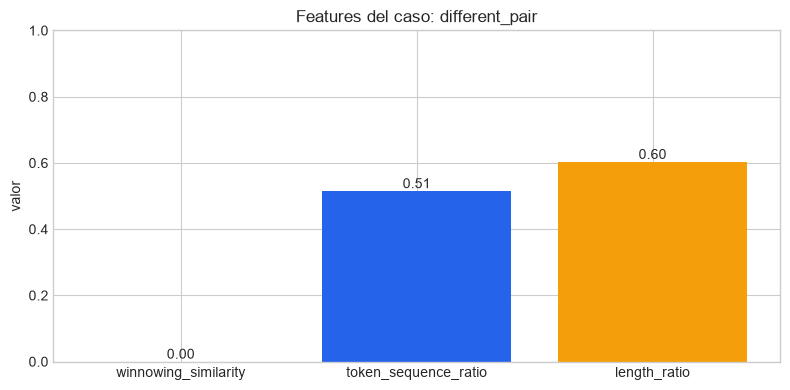

In [89]:
if not results_df.empty and "error" not in results_df.columns:
    plot_row = results_df.iloc[0]
    plot_features = ["winnowing_similarity", "token_sequence_ratio", "length_ratio"]
    plot_values = [float(plot_row.get(name, 0.0)) for name in plot_features]

    plt.style.use("seaborn-v0_8-whitegrid")
    fig, ax = plt.subplots(figsize=(8, 4))
    bars = ax.bar(plot_features, plot_values, color=["#0f766e", "#2563eb", "#f59e0b"])
    ax.set_ylim(0, 1)
    ax.set_ylabel("valor")
    ax.set_title(f"Features del caso: {plot_row['name']}")
    ax.bar_label(bars, fmt="%.2f")
    fig.tight_layout()

    figures_dir = Path("results")
    figures_dir.mkdir(exist_ok=True)
    fig_path = figures_dir / "feature_summary.png"
    fig.savefig(fig_path, dpi=150, bbox_inches="tight")
    print(f"Figura guardada en: {fig_path}")
else:
    print("No hay resultados válidos para graficar.")

## 7. Guardar y exportar notebook

Guardamos resultados intermedios en disco y dejamos comandos para exportar el notebook a HTML o PDF.

In [90]:
export_dir = Path("results")
export_dir.mkdir(exist_ok=True)

if not results_df.empty:
    csv_path = export_dir / "comparison_results.csv"
    json_path = export_dir / "comparison_results.json"
    results_df.to_csv(csv_path, index=False)
    results_df.to_json(json_path, orient="records", indent=2)
    print(f"Resultados guardados en: {csv_path}")
    print(f"Resultados guardados en: {json_path}")

nb_path = Path("plagiarism_model_test.ipynb")
html_cmd = f"jupyter nbconvert --to html {nb_path.name} --output-dir {export_dir}"
pdf_cmd = f"jupyter nbconvert --to pdf {nb_path.name} --output-dir {export_dir}"
print("Comando HTML:", html_cmd)
print("Comando PDF:", pdf_cmd)

Resultados guardados en: results\comparison_results.csv
Resultados guardados en: results\comparison_results.json
Comando HTML: jupyter nbconvert --to html plagiarism_model_test.ipynb --output-dir results
Comando PDF: jupyter nbconvert --to pdf plagiarism_model_test.ipynb --output-dir results


## 8. Uso del terminal integrado y panel de salida

Desde el terminal integrado puedes ejecutar el notebook, lanzar `pytest` o exportarlo con `nbconvert`. Los mensajes de salida aparecerán en la celda y también en el panel de salida del kernel.

## 9. Limpieza y reinicio del kernel

Limpia variables temporales y libera memoria. Si cambias paquetes o el modelo, reinicia el kernel antes de volver a ejecutar todo.

In [91]:
for name in ["test_dir", "test_file", "pytest_cmd", "completed", "plot_row", "plot_features", "plot_values"]:
    if name in globals():
        del globals()[name]

gc.collect()
print("Variables temporales eliminadas y memoria liberada.")
print("Si necesitas un estado limpio completo, reinicia el kernel desde VS Code y ejecuta de nuevo desde la primera celda.")

Variables temporales eliminadas y memoria liberada.
Si necesitas un estado limpio completo, reinicia el kernel desde VS Code y ejecuta de nuevo desde la primera celda.
